Using device: cuda
Загружаем файл S12-hw-dataset.csv
Всего наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 – 2025-06-29 23:00:00
Пропуски:
 date      0
target    0
dtype: int64


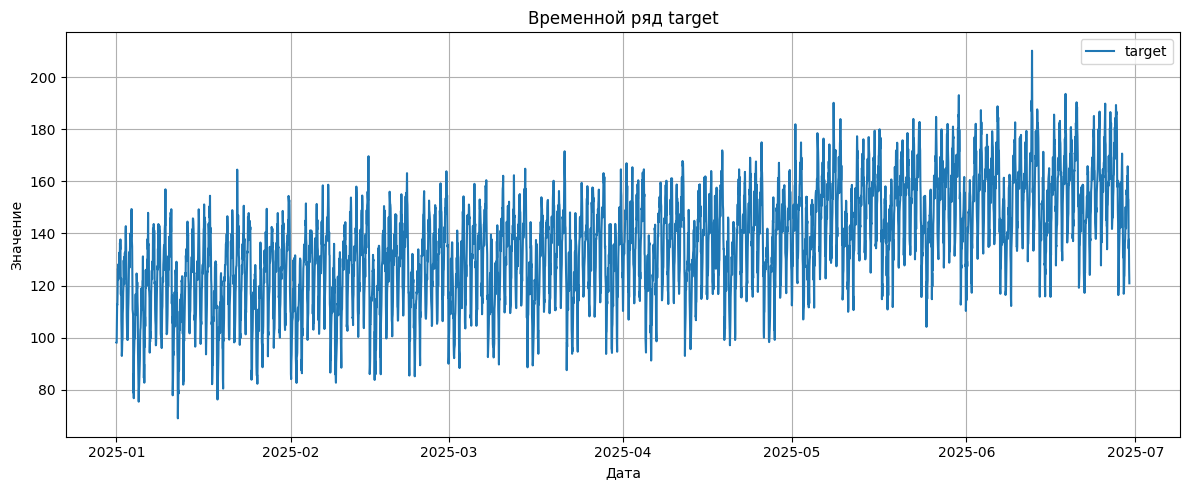

Train: 2025-01-01 00:00:00 – 2025-05-06 23:00:00  (3024 записей)
Val:   2025-05-07 00:00:00 – 2025-06-02 23:00:00    (648 записей)
Test:  2025-06-03 00:00:00 – 2025-06-29 23:00:00  (648 записей)


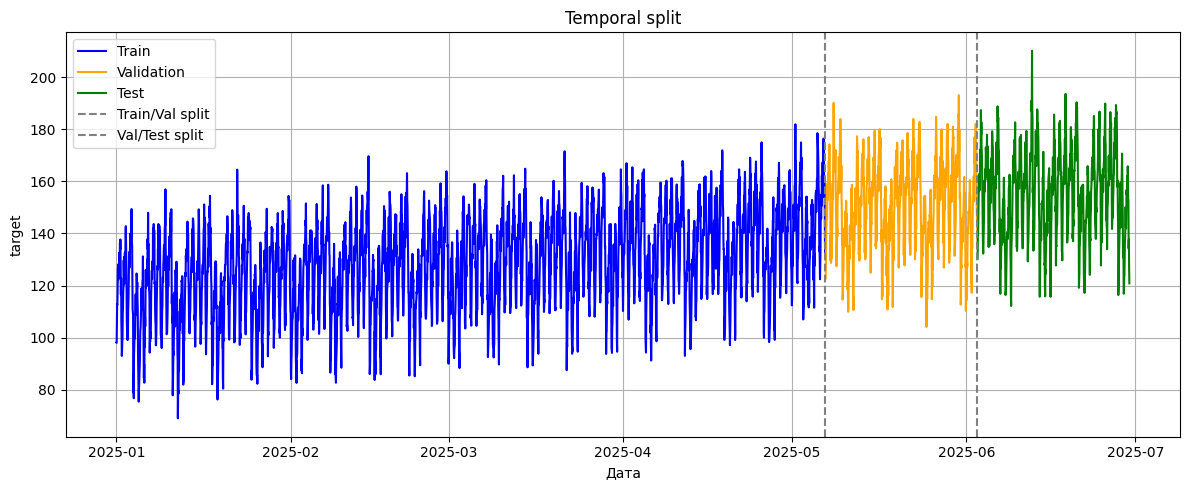

Train после удаления NaN: 3010
Val после удаления NaN:   648
Test после удаления NaN:  648
B1 val: MAE=6.439, RMSE=8.197, MAPE=4.39%
B1 test: MAE=6.341, RMSE=8.060, MAPE=4.15%
B2 val: MAE=12.711, RMSE=15.235, MAPE=8.82%
B2 test: MAE=12.740, RMSE=15.247, MAPE=8.55%
B3 val: MAE=6.680, RMSE=8.119, MAPE=4.43%
B3 test: MAE=6.801, RMSE=8.514, MAPE=4.33%


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("GRU", *args, **kwargs)
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/30, Train Loss: 0.578260, Val Loss: 0.389400
Epoch 2/30, Train Loss: 0.218825, Val Loss: 0.219803
Epoch 3/30, Train Loss: 0.154628, Val Loss: 0.197242
Epoch 4/30, Train Loss: 0.149687, Val Loss: 0.190358
Epoch 5/30, Train Loss: 0.148700, Val Loss: 0.188075
Epoch 6/30, Train Loss: 0.148039, Val Loss: 0.187092
Epoch 7/30, Train Loss: 0.147468, Val Loss: 0.186410
Epoch 8/30, Train Loss: 0.146963, Val Loss: 0.185774
Epoch 9/30, Train Loss: 0.146506, Val Loss: 0.185138
Epoch 10/30, Train Loss: 0.146083, Val Loss: 0.184517
Epoch 11/30, Train Loss: 0.145684, Val Loss: 0.183941
Epoch 12/30, Train Loss: 0.145301, Val Loss: 0.183447
Epoch 13/30, Train Loss: 0.144931, Val Loss: 0.183072
Epoch 14/30, Train Loss: 0.144573, Val Loss: 0.182839
Epoch 15/30, Train Loss: 0.144229, Val Loss: 0.182751
Epoch 16/30, Train Loss: 0.143901, Val Loss: 0.182785
Epoch 17/30, Train Loss: 0.143590, Val Loss: 0.182895
Epoch 18/30, Train Loss: 0.143295, Val Loss: 0.183031
Epoch 19/30, Train Loss: 0.143010, Va

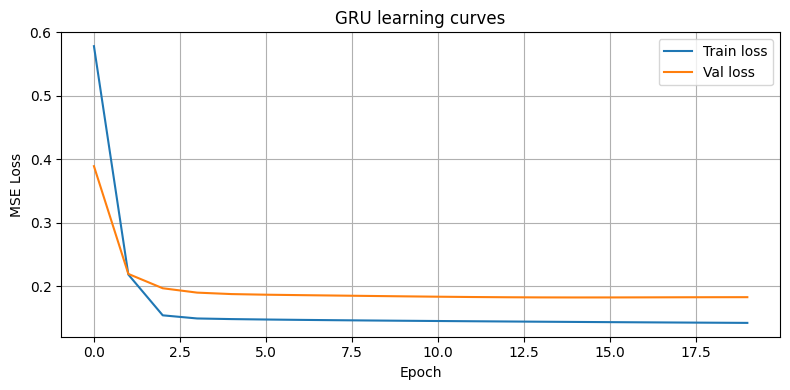

GRU val: MAE=6.305, RMSE=7.907, MAPE=4.23%
GRU test: MAE=6.645, RMSE=8.486, MAPE=4.27%
runs.csv сохранён
Конфигурация сохранена


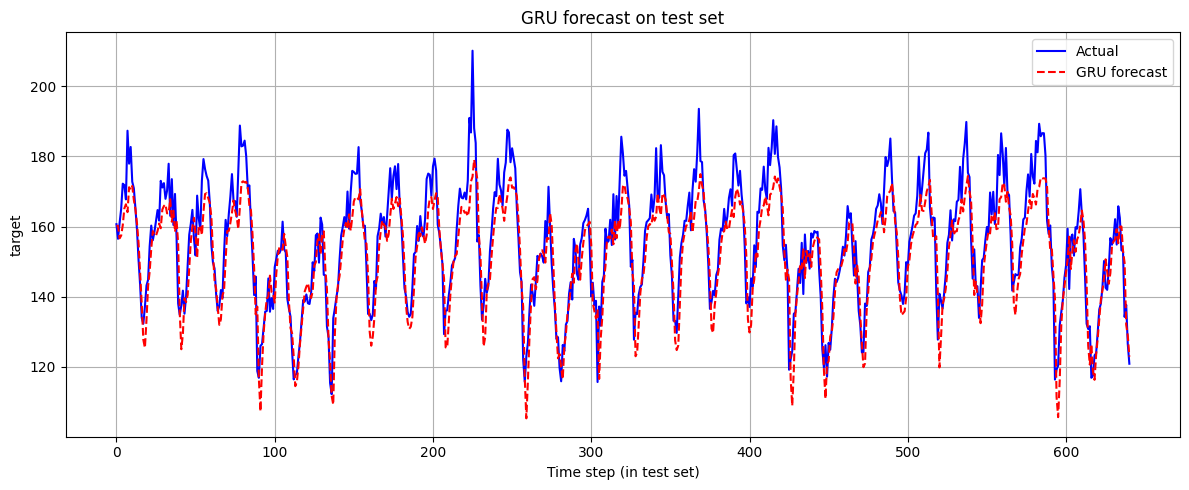

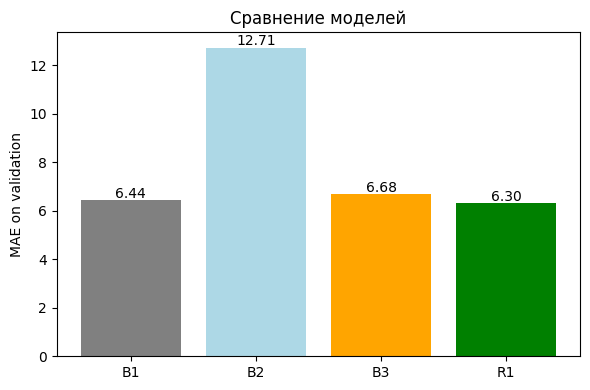

In [ ]:
# # HW12 – временные ряды: temporal split, baseline-модели и GRU-прогноз
# ## Импорты, seed, устройство

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Фиксируем seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Создаём папки для артефактов
os.makedirs("artifacts/figures", exist_ok=True)


# ## Загрузка и первичный анализ данных
# 
# Если файл `S12-hw-dataset.csv` не существует, создаём **уменьшенный** синтетический датасет для слабого железа.


data_path = "S12-hw-dataset.csv"

if not os.path.exists(data_path):
    print("Файл не найден. Генерируем синтетический датасет (уменьшенный для слабого железа)...")
    dates = pd.date_range(start="2020-01-01", end="2021-12-31", freq="D")
    n = len(dates)
    
    trend = np.linspace(100, 150, n)
    seasonal = 10 * np.sin(2 * np.pi * np.arange(n) / 365) + 5 * np.sin(2 * np.pi * np.arange(n) / 7)
    noise = np.random.normal(0, 3, n)
    target = trend + seasonal + noise
    external = np.cumsum(np.random.randn(n) * 0.5)
    
    df = pd.DataFrame({"date": dates, "target": target, "external": external})
    df.to_csv(data_path, index=False)
    print(f"Создан файл {data_path} (размер: {n} строк)")
else:
    print(f"Загружаем файл {data_path}")

df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Всего наблюдений: {len(df)}")
print(f"Диапазон дат: {df['date'].min()} – {df['date'].max()}")
print("Пропуски:\n", df.isnull().sum())

# Визуализация ряда
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["target"], label="target")
plt.title("Временной ряд target")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Ряд имеет явный восходящий тренд, годовую и недельную сезонность, а также некоторый шум.  
# Пропуски отсутствуют. Для слабого железа объём данных сокращён до 730 строк.


# ## Корректный temporal split (train / validation / test)


n = len(df)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_end = int(n * train_ratio)
val_end = train_end + int(n * val_ratio)

train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

print(f"Train: {train['date'].min()} – {train['date'].max()}  ({len(train)} записей)")
print(f"Val:   {val['date'].min()} – {val['date'].max()}    ({len(val)} записей)")
print(f"Test:  {test['date'].min()} – {test['date'].max()}  ({len(test)} записей)")

# Визуализация разбиения
plt.figure(figsize=(12, 5))
plt.plot(train["date"], train["target"], label="Train", color="blue")
plt.plot(val["date"], val["target"], label="Validation", color="orange")
plt.plot(test["date"], test["target"], label="Test", color="green")
plt.axvline(x=train["date"].iloc[-1], linestyle="--", color="gray", label="Train/Val split")
plt.axvline(x=val["date"].iloc[-1], linestyle="--", color="gray", label="Val/Test split")
plt.title("Temporal split")
plt.xlabel("Дата")
plt.ylabel("target")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("artifacts/figures/series_split.png", dpi=150)
plt.show()


# **Почему random split некорректен?**  
# Во временных рядах наблюдения зависимы по времени. Случайное перемешивание нарушило бы хронологический порядок, привело бы к утечке будущей информации в обучающую выборку и исказило бы оценку качества моделей.


# ## Построение признаков (лаги, rolling, календарные)

# %%
df_feat = df.copy()

df_feat["lag_1"] = df_feat["target"].shift(1)
df_feat["lag_7"] = df_feat["target"].shift(7)
df_feat["lag_14"] = df_feat["target"].shift(14)

df_feat["rolling_mean_7"] = df_feat["target"].rolling(7).mean()
df_feat["rolling_std_7"] = df_feat["target"].rolling(7).std()

df_feat["day_of_week"] = df_feat["date"].dt.dayofweek


# ## Подготовка для экспериментов


train_feat = df_feat.iloc[:train_end].copy()
val_feat = df_feat.iloc[train_end:val_end].copy()
test_feat = df_feat.iloc[val_end:].copy()

train_feat.dropna(inplace=True)
val_feat.dropna(inplace=True)
test_feat.dropna(inplace=True)

print(f"Train после удаления NaN: {len(train_feat)}")
print(f"Val после удаления NaN:   {len(val_feat)}")
print(f"Test после удаления NaN:  {len(test_feat)}")

feature_cols = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "day_of_week"]
X_train = train_feat[feature_cols]
y_train = train_feat["target"]
X_val = val_feat[feature_cols]
y_val = val_feat["target"]
X_test = test_feat[feature_cols]
y_test = test_feat["target"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# ## Эксперимент B1: наивный прогноз (last observation)


y_pred_b1_val = val_feat["target"].shift(1).dropna()
y_true_b1_val = val_feat["target"].iloc[1:]

y_pred_b1_test = test_feat["target"].shift(1).dropna()
y_true_b1_test = test_feat["target"].iloc[1:]

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

mae_b1_val, rmse_b1_val, mape_b1_val = compute_metrics(y_true_b1_val, y_pred_b1_val)
print(f"B1 val: MAE={mae_b1_val:.3f}, RMSE={rmse_b1_val:.3f}, MAPE={mape_b1_val:.2f}%")

mae_b1_test, rmse_b1_test, mape_b1_test = compute_metrics(y_true_b1_test, y_pred_b1_test)
print(f"B1 test: MAE={mae_b1_test:.3f}, RMSE={rmse_b1_test:.3f}, MAPE={mape_b1_test:.2f}%")


# ## Эксперимент B2: скользящее среднее (window=7)


window = 7
y_pred_b2_val = val_feat["target"].rolling(window).mean().shift(1).dropna()
y_true_b2_val = val_feat["target"].iloc[window:]

y_pred_b2_test = test_feat["target"].rolling(window).mean().shift(1).dropna()
y_true_b2_test = test_feat["target"].iloc[window:]

mae_b2_val, rmse_b2_val, mape_b2_val = compute_metrics(y_true_b2_val, y_pred_b2_val)
print(f"B2 val: MAE={mae_b2_val:.3f}, RMSE={rmse_b2_val:.3f}, MAPE={mape_b2_val:.2f}%")

mae_b2_test, rmse_b2_test, mape_b2_test = compute_metrics(y_true_b2_test, y_pred_b2_test)
print(f"B2 test: MAE={mae_b2_test:.3f}, RMSE={rmse_b2_test:.3f}, MAPE={mape_b2_test:.2f}%")


# ## Эксперимент B3: Ridge на лаговых, rolling и календарных признаках

# %%
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_b3_val = ridge.predict(X_val_scaled)
mae_b3_val, rmse_b3_val, mape_b3_val = compute_metrics(y_val, y_pred_b3_val)
print(f"B3 val: MAE={mae_b3_val:.3f}, RMSE={rmse_b3_val:.3f}, MAPE={mape_b3_val:.2f}%")

y_pred_b3_test = ridge.predict(X_test_scaled)
mae_b3_test, rmse_b3_test, mape_b3_test = compute_metrics(y_test, y_pred_b3_test)
print(f"B3 test: MAE={mae_b3_test:.3f}, RMSE={rmse_b3_test:.3f}, MAPE={mape_b3_test:.2f}%")


# ## Подготовка данных для GRU (оконное представление)


target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = target_scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

window_size = 7

class TimeSeriesDataset(Dataset):
    def __init__(self, series, window):
        self.series = series
        self.window = window
        self.X = []
        self.y = []
        for i in range(len(series) - window):
            self.X.append(series[i:i+window])
            self.y.append(series[i+window])
        self.X = np.array(self.X, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

train_dataset = TimeSeriesDataset(y_train_scaled, window_size)
val_dataset = TimeSeriesDataset(y_val_scaled, window_size)
test_dataset = TimeSeriesDataset(y_test_scaled, window_size)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# ## Определение GRU-модели (уменьшенная архитектура)


class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = GRUModel(input_size=1, hidden_size=16, num_layers=1, dropout=0.2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# ## Обучение GRU (с ранней остановкой и уменьшенным числом эпох)


num_epochs = 30
best_val_loss = float('inf')
train_losses = []
val_losses = []
patience = 5
wait = 0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.unsqueeze(-1).to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        output = model(X_batch).squeeze()
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    
    avg_train_loss = total_loss / len(train_dataset)
    train_losses.append(avg_train_loss)
    
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.unsqueeze(-1).to(device)
            y_batch = y_batch.to(device)
            output = model(X_batch).squeeze()
            loss = criterion(output, y_batch)
            total_val_loss += loss.item() * len(X_batch)
    avg_val_loss = total_val_loss / len(val_dataset)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "artifacts/best_gru.pt")
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# График обучения
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("GRU learning curves")
plt.grid(True)
plt.tight_layout()
plt.savefig("artifacts/figures/gru_learning_curves.png", dpi=150)
plt.show()


# ## Оценка GRU на валидации и тесте


model.load_state_dict(torch.load("artifacts/best_gru.pt", map_location=device))
model.eval()

def evaluate_gru(model, loader, target_scaler):
    preds = []
    trues = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.unsqueeze(-1).to(device)
            output = model(X_batch).squeeze().cpu().numpy()
            if output.ndim == 0:
                output = [output]
            preds.extend(output)
            trues.extend(y_batch.numpy())
    preds = np.array(preds)
    trues = np.array(trues)
    preds = target_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
    trues = target_scaler.inverse_transform(trues.reshape(-1, 1)).flatten()
    return compute_metrics(trues, preds)

mae_gru_val, rmse_gru_val, mape_gru_val = evaluate_gru(model, val_loader, target_scaler)
print(f"GRU val: MAE={mae_gru_val:.3f}, RMSE={rmse_gru_val:.3f}, MAPE={mape_gru_val:.2f}%")

mae_gru_test, rmse_gru_test, mape_gru_test = evaluate_gru(model, test_loader, target_scaler)
print(f"GRU test: MAE={mae_gru_test:.3f}, RMSE={rmse_gru_test:.3f}, MAPE={mape_gru_test:.2f}%")


# ## Сохранение результатов в runs.csv


results = pd.DataFrame([
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "train 70%, val 15%, test 15% (chronological)",
        "window_size": "-",
        "horizon": 1,
        "model_summary": "naive-last",
        "features_summary": "none",
        "scaler": "none",
        "optimizer": "-",
        "lr": "-",
        "epochs_trained": "-",
        "best_val_mae": mae_b1_val,
        "best_val_rmse": rmse_b1_val,
        "best_val_mape": mape_b1_val,
        "test_mae": mae_b1_test,
        "test_rmse": rmse_b1_test,
        "test_mape": mape_b1_test,
        "notes": "naive forecast: predict previous value"
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "train 70%, val 15%, test 15% (chronological)",
        "window_size": 7,
        "horizon": 1,
        "model_summary": "moving-average",
        "features_summary": "none",
        "scaler": "none",
        "optimizer": "-",
        "lr": "-",
        "epochs_trained": "-",
        "best_val_mae": mae_b2_val,
        "best_val_rmse": rmse_b2_val,
        "best_val_mape": mape_b2_val,
        "test_mae": mae_b2_test,
        "test_rmse": rmse_b2_test,
        "test_mape": mape_b2_test,
        "notes": "rolling mean with window 7"
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "train 70%, val 15%, test 15% (chronological)",
        "window_size": "-",
        "horizon": 1,
        "model_summary": "Ridge regression",
        "features_summary": "lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week",
        "scaler": "StandardScaler (fit on train)",
        "optimizer": "-",
        "lr": "-",
        "epochs_trained": "-",
        "best_val_mae": mae_b3_val,
        "best_val_rmse": rmse_b3_val,
        "best_val_mape": mape_b3_val,
        "test_mae": mae_b3_test,
        "test_rmse": rmse_b3_test,
        "test_mape": mape_b3_test,
        "notes": "linear model with features"
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "train 70%, val 15%, test 15% (chronological)",
        "window_size": window_size,
        "horizon": 1,
        "model_summary": "GRU (hidden=16, layers=1, dropout=0.2)",
        "features_summary": "sequence of target values",
        "scaler": "StandardScaler on target (fit on train)",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": num_epochs,
        "best_val_mae": mae_gru_val,
        "best_val_rmse": rmse_gru_val,
        "best_val_mape": mape_gru_val,
        "test_mae": mae_gru_test,
        "test_rmse": rmse_gru_test,
        "test_mape": mape_gru_test,
        "notes": "best model by validation loss"
    }
])

results.to_csv("artifacts/runs.csv", index=False)
print("runs.csv сохранён")


# ## Сохранение конфигурации лучшей GRU


config = {
    "model_type": "GRU",
    "input_size": 1,
    "hidden_size": 16,
    "num_layers": 1,
    "dropout": 0.2,
    "window_size": window_size,
    "batch_size": batch_size,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "loss": "MSE",
    "seed": SEED,
    "scaler": "StandardScaler (fit on train)",
    "best_val_loss": best_val_loss,
    "num_epochs": num_epochs,
    "early_stopping": patience
}

with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=4)
print("Конфигурация сохранена")


# ## Финальный прогноз на тесте (график)


model.eval()
preds = []
trues = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.unsqueeze(-1).to(device)
        output = model(X_batch).squeeze().cpu().numpy()
        if output.ndim == 0:
            output = [output]
        preds.extend(output)
        trues.extend(y_batch.numpy())
preds = np.array(preds)
trues = np.array(trues)
preds = target_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
trues = target_scaler.inverse_transform(trues.reshape(-1, 1)).flatten()

plt.figure(figsize=(12, 5))
plt.plot(trues, label="Actual", color="blue")
plt.plot(preds, label="GRU forecast", color="red", linestyle="--")
plt.title("GRU forecast on test set")
plt.xlabel("Time step (in test set)")
plt.ylabel("target")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("artifacts/figures/best_forecast_test.png", dpi=150)
plt.show()


# ## Сравнение всех моделей (график)


models = ["B1", "B2", "B3", "R1"]
val_mae = [mae_b1_val, mae_b2_val, mae_b3_val, mae_gru_val]

plt.figure(figsize=(6, 4))
plt.bar(models, val_mae, color=['gray', 'lightblue', 'orange', 'green'])
plt.ylabel("MAE on validation")
plt.title("Сравнение моделей")
for i, v in enumerate(val_mae):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png", dpi=150)
plt.show()